<a href="https://colab.research.google.com/github/xiqizheng/chapter4manuscript_NDVILST/blob/main/species_specialization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Conect google drive with colab**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Specilization Index Calculation**

In [ ]:
print(zonal.columns.tolist())

['OBJECTID', 'site_name', 'site_point', 'laitude', 'longitude', 'NDVI_2023', 'NDVI_2024', 'NDVI_2025', 'Temperature_2023', 'Temperature_2024', 'Temperature_2025', 'LST_2023_LandSat1', 'LST_2024_LandSat1', 'LST_2025_LandSat1', 'LST_2023_LandSat2', 'LST_2024_LandSat2', 'LST_2025_LandSat2', 'NDVI_2023_LandSat1', 'NDVI_2024_LandSat1', 'NDVI_2025_LandSat1', 'NDVI_2023_LandSat2', 'NDVI_2024_LandSat2', 'NDVI_2025_LandSat2', 'NDVI_2023_LandSat', 'NDVI_2024_LandSat', 'NDVI_2024_LandSat.1']


In [ ]:
import pandas as pd
import numpy as np

bird_file = "/content/drive/MyDrive/point_count/Specilization/Point_Counts_Scoring_Xiqiversion.xlsx"
zonal_file = "/content/drive/MyDrive/point_count/zonaldata.xlsx"

birds = pd.read_excel(bird_file)
zonal = pd.read_excel(zonal_file)

birds = birds.loc[:, ~birds.columns.astype(str).str.contains("^Unnamed")]
zonal = zonal.loc[:, ~zonal.columns.astype(str).str.contains("^Unnamed")]

birds.columns = birds.columns.astype(str).str.strip()
zonal.columns = zonal.columns.astype(str).str.strip()

print("Zonal columns:", zonal.columns.tolist())

birds["site"] = birds["site"].astype(str).str.strip().str.lower()
zonal["site_name"] = zonal["site_name"].astype(str).str.strip().str.lower()

birds["Transect"] = pd.to_numeric(birds["Transect"], errors="coerce")
zonal["site_point"] = pd.to_numeric(zonal["site_point"], errors="coerce")
birds["# seen"] = pd.to_numeric(birds["# seen"], errors="coerce")

env_cols = [
    "NDVI_2023_LandSat2", "NDVI_2024_LandSat2", "NDVI_2025_LandSat2",
    "LST_2023_LandSat2", "LST_2024_LandSat2", "LST_2025_LandSat2"
]

for col in env_cols:
    if col not in zonal.columns:
        raise KeyError(f"Missing column in zonaldata.xlsx: {col}")
    zonal[col] = pd.to_numeric(zonal[col], errors="coerce")

data = birds.merge(
    zonal,
    left_on=["site", "Transect"],
    right_on=["site_name", "site_point"],
    how="left"
)

print("Merged rows:", len(data))
print("Unique species:", data["Species"].nunique())
print("Unique site-transect combos:", data[["site", "Transect"]].drop_duplicates().shape[0])

keep_cols = [
    "site", "Transect", "Species", "# seen", "date", "time", "Round",
    "NDVI_2023_LandSat2", "NDVI_2024_LandSat2", "NDVI_2025_LandSat2",
    "LST_2023_LandSat2", "LST_2024_LandSat2", "LST_2025_LandSat2"
]

data = data[keep_cols].copy()

data = data.rename(columns={
    "Species": "species",
    "# seen": "count",
    "Transect": "transect"
})

for yr in ["2023", "2024", "2025"]:
    print(f"Missing NDVI_{yr} after merge:", data[f"NDVI_{yr}_LandSat2"].isna().sum())
    print(f"Missing LST_{yr} after merge:", data[f"LST_{yr}_LandSat2"].isna().sum())

long_frames = []

for yr in ["2023", "2024", "2025"]:
    temp = data[[
        "site", "transect", "species", "count", "date", "time", "Round",
        f"NDVI_{yr}_LandSat2", f"LST_{yr}_LandSat2"
    ]].copy()

    temp = temp.rename(columns={
        f"NDVI_{yr}_LandSat2": "ndvi",
        f"LST_{yr}_LandSat2": "lst"
    })

    temp["year"] = int(yr)
    long_frames.append(temp)

data_long = pd.concat(long_frames, ignore_index=True)
data_long = data_long.dropna(subset=["species", "ndvi", "lst"]).copy()

print("\nLong-format rows:", len(data_long))
print("Years included:", sorted(data_long["year"].unique()))

species_summary = (
    data_long.groupby("species")
    .agg(
        n_records=("species", "size"),
        n_sites=("site", "nunique"),
        n_years=("year", "nunique"),
        total_count=("count", "sum"),
        ndvi_mean=("ndvi", "mean"),
        ndvi_sd=("ndvi", "std"),
        ndvi_min=("ndvi", "min"),
        ndvi_max=("ndvi", "max"),
        lst_mean=("lst", "mean"),
        lst_sd=("lst", "std"),
        lst_min=("lst", "min"),
        lst_max=("lst", "max")
    )
    .reset_index()
)

species_summary["ndvi_sd"] = species_summary["ndvi_sd"].fillna(0)
species_summary["lst_sd"] = species_summary["lst_sd"].fillna(0)

species_summary["ndvi_range"] = species_summary["ndvi_max"] - species_summary["ndvi_min"]
species_summary["lst_range"] = species_summary["lst_max"] - species_summary["lst_min"]

species_summary = species_summary[
    (species_summary["n_records"] >= 3) &
    (species_summary["n_sites"] >= 2)
].copy()

print("\nSpecies retained after filtering:", len(species_summary))

def minmax_scale(series):
    smin = series.min()
    smax = series.max()
    if smax == smin:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - smin) / (smax - smin)

species_summary["ndvi_sd_scaled"] = minmax_scale(species_summary["ndvi_sd"])
species_summary["lst_sd_scaled"] = minmax_scale(species_summary["lst_sd"])

species_summary["env_breadth"] = (
    species_summary["ndvi_sd_scaled"] + species_summary["lst_sd_scaled"]
) / 2

species_summary["specialization_raw"] = 1 - species_summary["env_breadth"]
species_summary["specialization_index"] = minmax_scale(species_summary["specialization_raw"])

species_summary["specialization_class"] = pd.qcut(
    species_summary["specialization_index"],
    q=3,
    labels=["generalist", "intermediate", "specialist"],
    duplicates="drop"
)

species_summary = species_summary.sort_values(
    by="specialization_index",
    ascending=False
).reset_index(drop=True)

data.to_csv("bird_env_merged_wide_LandSat2.csv", index=False)
data_long.to_csv("bird_env_merged_long_LandSat2_2023_2025.csv", index=False)
species_summary.to_csv("species_specialization_index_LandSat2_2023_2025.csv", index=False)

print("\nTop 15 most specialized species:")
print(species_summary[
    [
        "species", "n_records", "n_sites", "n_years",
        "ndvi_sd", "lst_sd", "env_breadth",
        "specialization_index", "specialization_class"
    ]
].head(15))

print("\nTop 15 most generalist species:")
print(species_summary[
    [
        "species", "n_records", "n_sites", "n_years",
        "ndvi_sd", "lst_sd", "env_breadth",
        "specialization_index", "specialization_class"
    ]
].tail(15))

Zonal columns: ['OBJECTID', 'site_name', 'site_point', 'laitude', 'longitude', 'NDVI_2023', 'NDVI_2024', 'NDVI_2025', 'Temperature_2023', 'Temperature_2024', 'Temperature_2025', 'LST_2023_LandSat1', 'LST_2024_LandSat1', 'LST_2025_LandSat1', 'LST_2023_LandSat2', 'LST_2024_LandSat2', 'LST_2025_LandSat2', 'NDVI_2023_LandSat1', 'NDVI_2024_LandSat1', 'NDVI_2025_LandSat1', 'NDVI_2023_LandSat2', 'NDVI_2024_LandSat2', 'NDVI_2025_LandSat2', 'NDVI_2023_LandSat', 'NDVI_2024_LandSat', 'NDVI_2024_LandSat.1']
Merged rows: 2655
Unique species: 88
Unique site-transect combos: 101
Missing NDVI_2023 after merge: 33
Missing LST_2023 after merge: 33
Missing NDVI_2024 after merge: 33
Missing LST_2024 after merge: 33
Missing NDVI_2025 after merge: 33
Missing LST_2025 after merge: 33

Long-format rows: 7866
Years included: [np.int64(2023), np.int64(2024), np.int64(2025)]

Species retained after filtering: 51

Top 15 most specialized species:
   species  n_records  n_sites  n_years   ndvi_sd    lst_sd  env_br

# **Make Specilization Plots**

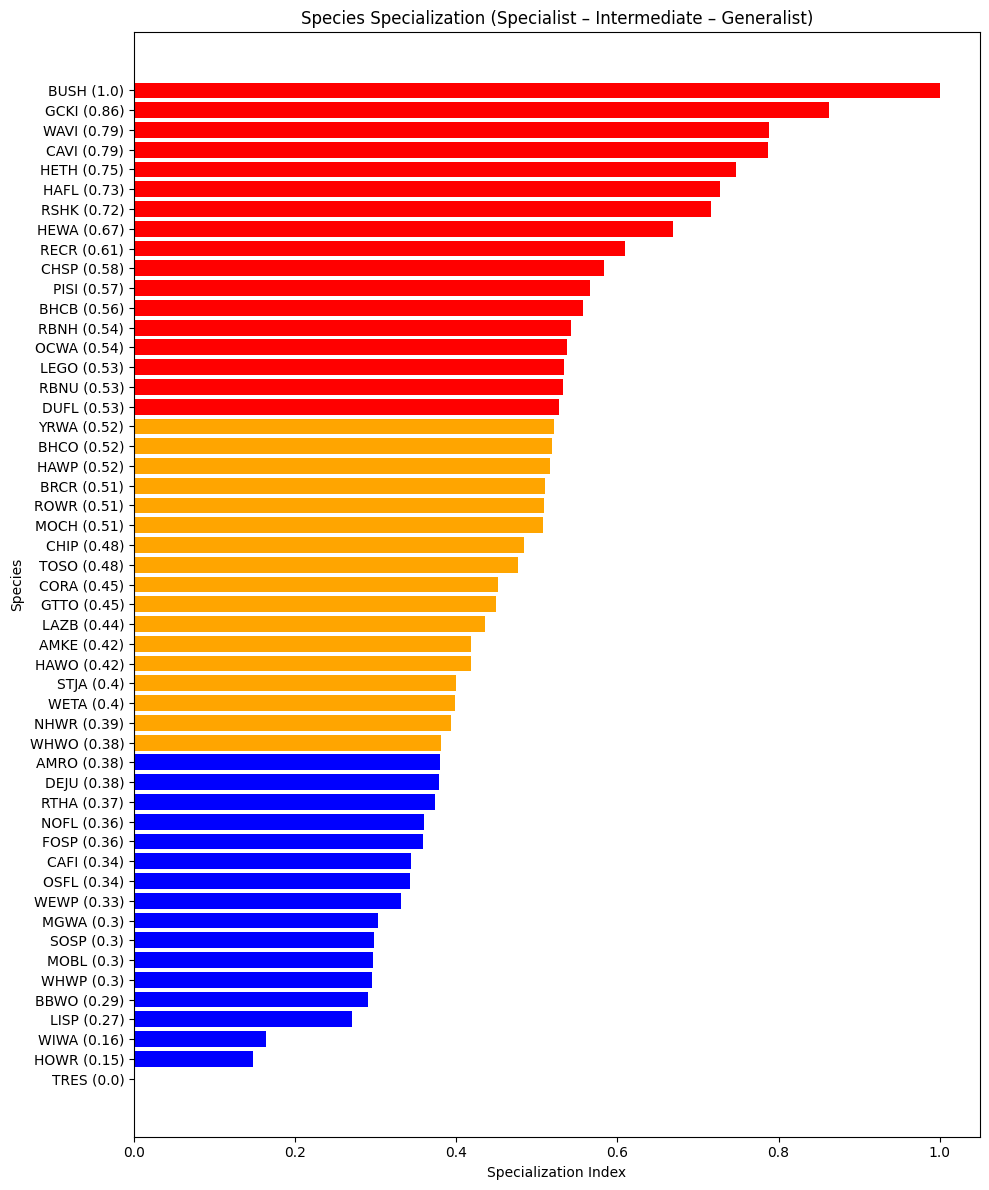

In [ ]:
import matplotlib.pyplot as plt

# =========================
# 1. order
# =========================
result_table = species_summary.sort_values(
    by="specialization_index",
    ascending=False
).reset_index(drop=True)

# =========================
# 2.  top / bottom
# =========================
top10 = result_table.head(10).copy()
bottom10 = result_table.tail(10).copy()

# =========================
# 3. label
# =========================
top10["label"] = top10["species"] + " (" + top10["specialization_index"].round(2).astype(str) + ")"
bottom10["label"] = bottom10["species"] + " (" + bottom10["specialization_index"].round(2).astype(str) + ")"

import matplotlib.pyplot as plt

# =========================
# 1. order
# =========================
result_table = species_summary.sort_values(
    by="specialization_index",
    ascending=False
).reset_index(drop=True)

# =========================
# 2. color
# =========================
color_map = {
    "specialist": "red",
    "intermediate": "orange",
    "generalist": "blue"
}

colors = result_table["specialization_class"].map(color_map)

# =========================
# 3. label（species + index）
# =========================
labels = result_table["species"] + " (" + result_table["specialization_index"].round(2).astype(str) + ")"

# =========================
# 4. plot
# =========================
plt.figure(figsize=(10, 12))

plt.barh(labels, result_table["specialization_index"], color=colors)

plt.xlabel("Specialization Index")
plt.ylabel("Species")
plt.title("Species Specialization (Specialist – Intermediate – Generalist)")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## **This is just download output spreadsheets, see which version of Python we use, and spreadsheet heading check code**

In [ ]:
# save
species_summary.to_excel("species_specialization_table.xlsx", index=False)

# check
import os
print(os.listdir())

# download
from google.colab import files
files.download("species_specialization_table.xlsx")

['.config', 'species_fire_tolerance_index.xlsx', 'bird_env_merged_wide_LandSat2.csv', 'NDVIL1_added.xlsx', 'final_analysis_output.xlsx', 'species_specialization_table.xlsx', 'species_specialization_index_LandSat2_2023_2025.csv', 'bird_env_merged_long_LandSat2_2023_2025.csv', 'ndvi_burned_unburned.png', 'overall_burned_unburned_ndvi_lst.xlsx', 'yearly_ndvi_lst_significance.xlsx', 'yearly_burned_unburned_ndvi_lst.xlsx', 'lst_yearly_comparison.png', 'NDVI_added.xlsx', 'specialization_with_fire_tolerance.xlsx', 'ndvi_yearly_comparison.png', 'lst_burned_unburned.png', 'drive', 'sample_data']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


# **combine time series NDVI map image to one image**

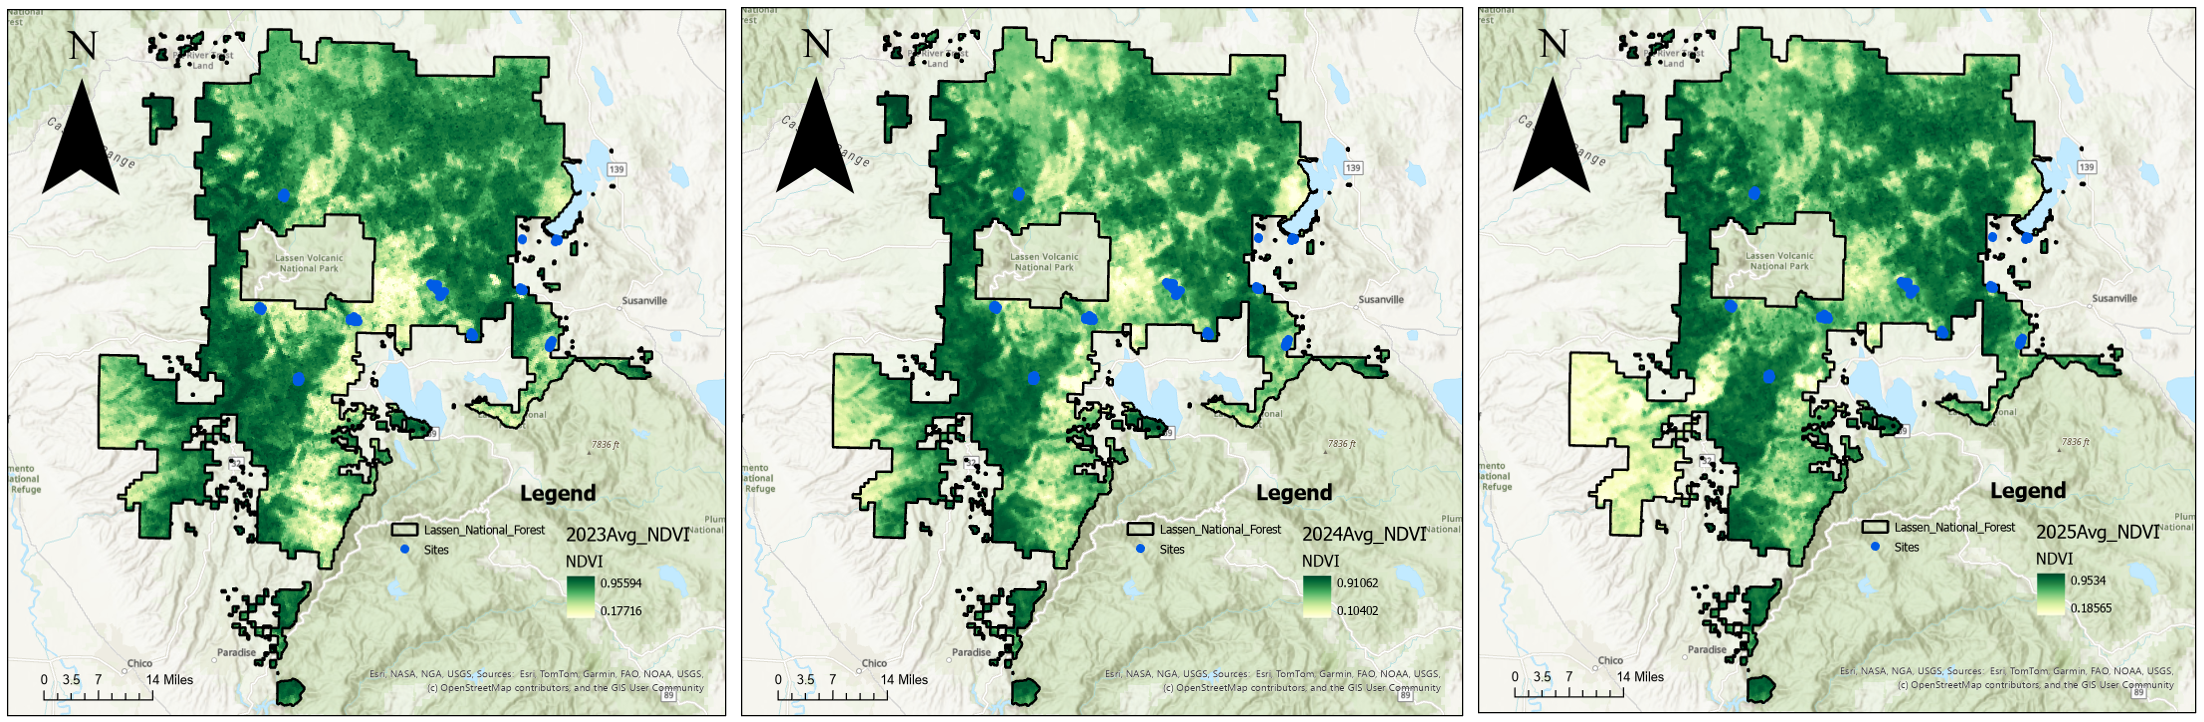

In [ ]:
from PIL import Image

# read file
img1 = Image.open("/content/drive/MyDrive/point_count/Specilization/2023avgNDVI.png")
img2 = Image.open("/content/drive/MyDrive/point_count/Specilization/2024avgNDVI.png")
img3 = Image.open("/content/drive/MyDrive/point_count/Specilization/2025avgNDVI.png")

# same height
height = min(img1.height, img2.height, img3.height)

def resize(img, h):
    return img.resize((int(img.width * h / img.height), h))

img1 = resize(img1, height)
img2 = resize(img2, height)
img3 = resize(img3, height)

# creat horizontal canvas
total_width = img1.width + img2.width + img3.width
new_img = Image.new("RGB", (total_width, height))

# aline together
x_offset = 0
for img in [img1, img2, img3]:
    new_img.paste(img, (x_offset, 0))
    x_offset += img.width

# save
new_img.save("combined.png")

new_img

# **combine time series LST map image to one image**

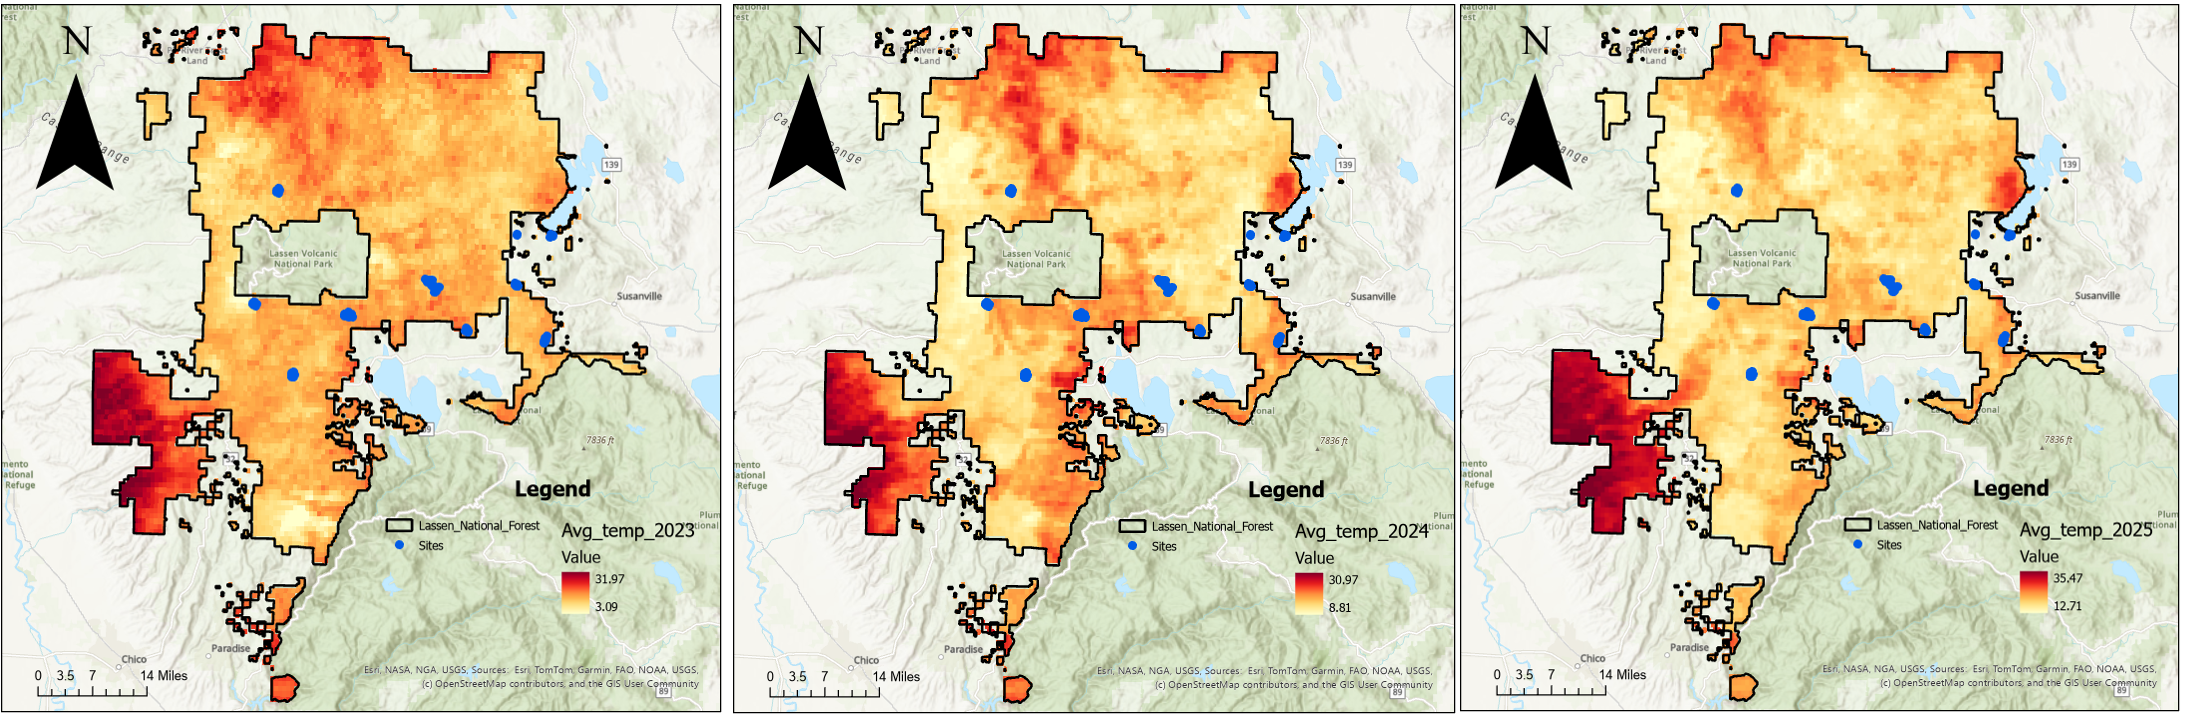

In [ ]:
from PIL import Image

# read file
img1 = Image.open("/content/drive/MyDrive/point_count/Specilization/2023avgtemp.png")
img2 = Image.open("/content/drive/MyDrive/point_count/Specilization/2024avgtemp.png")
img3 = Image.open("/content/drive/MyDrive/point_count/Specilization/2025avgtemp.png")

# same height
height = min(img1.height, img2.height, img3.height)

def resize(img, h):
    return img.resize((int(img.width * h / img.height), h))

img1 = resize(img1, height)
img2 = resize(img2, height)
img3 = resize(img3, height)

# creat horizontal canvas
total_width = img1.width + img2.width + img3.width
new_img = Image.new("RGB", (total_width, height))

# aline together
x_offset = 0
for img in [img1, img2, img3]:
    new_img.paste(img, (x_offset, 0))
    x_offset += img.width

# save
new_img.save("combined.png")

new_img

# **combine types of specilization index plots to one image**

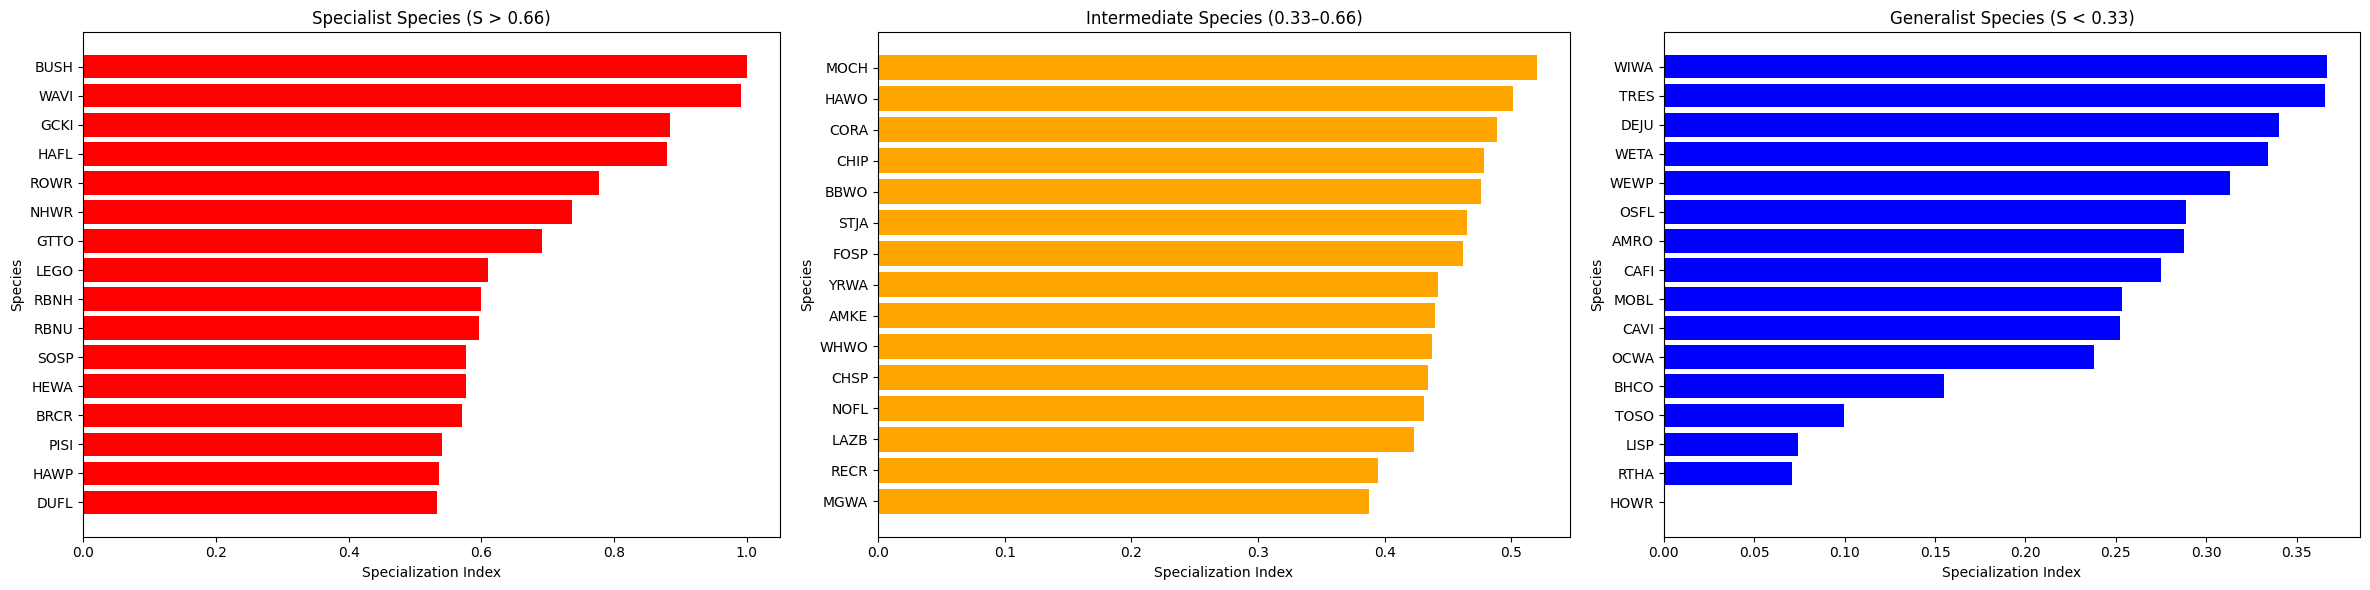

In [ ]:
from PIL import Image

# read file
img1 = Image.open("/content/drive/MyDrive/point_count/Specilization/specialist.png")
img2 = Image.open("/content/drive/MyDrive/point_count/Specilization/intermediate.png")
img3 = Image.open("/content/drive/MyDrive/point_count/Specilization/generalist.png")

# same height
height = min(img1.height, img2.height, img3.height)

def resize(img, h):
    return img.resize((int(img.width * h / img.height), h))

img1 = resize(img1, height)
img2 = resize(img2, height)
img3 = resize(img3, height)

# creat horizontal canvas
total_width = img1.width + img2.width + img3.width
new_img = Image.new("RGB", (total_width, height))

# aline together
x_offset = 0
for img in [img1, img2, img3]:
    new_img.paste(img, (x_offset, 0))
    x_offset += img.width

# save
new_img.save("combined.png")

new_img

# **Specilization and burn sites plots**

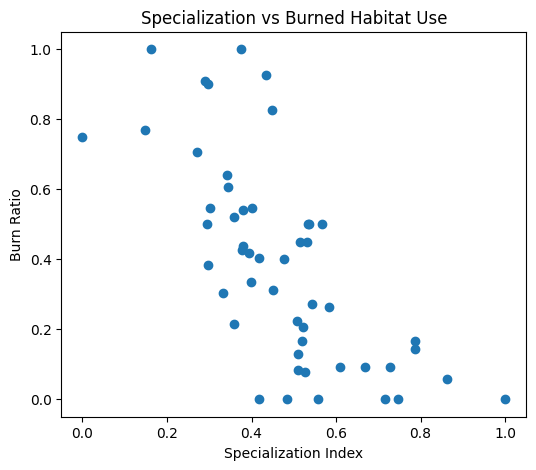

In [ ]:
# -------------------------
# 1. define burn sites
# -------------------------
burn_sites = ["ember", "chester", "victory", "silver", "cinn"]
unburned_sites = ["eldin", "river", "lassen", "johto", "eagle"]

# -------------------------
# 2. add burn label (USE data_long)
# -------------------------
data_long["site_clean"] = data_long["site"].str.lower()

data_long["burn_status"] = data_long["site_clean"].apply(
    lambda x: "burned" if x in burn_sites else "unburned"
)

# -------------------------
# 3. calculate burn ratio
# -------------------------
burn_summary = (
    data_long.groupby(["species", "burn_status"])
    .size()
    .unstack(fill_value=0)
)

burn_summary["burn_ratio"] = (
    burn_summary["burned"] /
    (burn_summary["burned"] + burn_summary["unburned"])
)

burn_summary = burn_summary.reset_index()

# -------------------------
# 4. merge with specialization
# -------------------------
final = species_summary.merge(
    burn_summary[["species", "burn_ratio"]],
    on="species",
    how="left"
)
# -------------------------
# 5. plot
# -------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(
    final["specialization_index"],
    final["burn_ratio"]
)

plt.xlabel("Specialization Index")
plt.ylabel("Burn Ratio")
plt.title("Specialization vs Burned Habitat Use")

plt.show()


In [ ]:
print("Species in species_summary:", len(species_summary))

Species in species_summary: 88


In [ ]:
species_summary_filtered = species_summary[
    (species_summary["n_records"] >= 3) &
    (species_summary["n_sites"] >= 2)
].copy()

print("Filtered species:", len(species_summary_filtered))

burned_sites = ["ember", "chester", "victory", "silver", "cinn"]

data_long["burned"] = data_long["site"].isin(burned_sites)

burn_ratio_filtered = (
    data_long
    .groupby("species")["burned"]
    .mean()
    .reset_index(name="burn_ratio")
)

burn_ratio_filtered = burn_ratio_filtered[
    burn_ratio_filtered["species"].isin(species_summary_filtered["species"])
].copy()

print("Filtered burn ratio species:", len(burn_ratio_filtered))

burn_ratio_filtered.to_excel("burn_ratio_filtered_51_species.xlsx", index=False)

from google.colab import files
files.download("burn_ratio_filtered_51_species.xlsx")

Filtered species: 51
Filtered burn ratio species: 51


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
from google.colab import files

bird_file = "/content/drive/MyDrive/point_count/Specilization/Point_Counts_Scoring_Xiqiversion.xlsx"
zonal_file = "/content/drive/MyDrive/point_count/zonaldata.xlsx"

birds = pd.read_excel(bird_file)
zonal = pd.read_excel(zonal_file)

birds = birds.loc[:, ~birds.columns.astype(str).str.contains("^Unnamed")]
zonal = zonal.loc[:, ~zonal.columns.astype(str).str.contains("^Unnamed")]

birds.columns = birds.columns.astype(str).str.strip()
zonal.columns = zonal.columns.astype(str).str.strip()

birds["site"] = birds["site"].astype(str).str.strip().str.lower()
zonal["site_name"] = zonal["site_name"].astype(str).str.strip().str.lower()

birds["Transect"] = pd.to_numeric(birds["Transect"], errors="coerce")
zonal["site_point"] = pd.to_numeric(zonal["site_point"], errors="coerce")
birds["# seen"] = pd.to_numeric(birds["# seen"], errors="coerce")

env_cols = [
    "NDVI_2023_LandSat2", "NDVI_2024_LandSat2", "NDVI_2025_LandSat2",
    "LST_2023_LandSat2", "LST_2024_LandSat2", "LST_2025_LandSat2"
]

for col in env_cols:
    zonal[col] = pd.to_numeric(zonal[col], errors="coerce")

data = birds.merge(
    zonal,
    left_on=["site", "Transect"],
    right_on=["site_name", "site_point"],
    how="left"
)

data = data[[
    "site", "Transect", "Species", "# seen", "date", "time", "Round",
    "NDVI_2023_LandSat2", "NDVI_2024_LandSat2", "NDVI_2025_LandSat2",
    "LST_2023_LandSat2", "LST_2024_LandSat2", "LST_2025_LandSat2"
]].copy()

data = data.rename(columns={
    "Species": "species",
    "# seen": "count",
    "Transect": "transect"
})

long_frames = []

for yr in ["2023", "2024", "2025"]:
    temp = data[[
        "site", "transect", "species", "count", "date", "time", "Round",
        f"NDVI_{yr}_LandSat2", f"LST_{yr}_LandSat2"
    ]].copy()

    temp = temp.rename(columns={
        f"NDVI_{yr}_LandSat2": "ndvi",
        f"LST_{yr}_LandSat2": "lst"
    })

    temp["year"] = int(yr)
    long_frames.append(temp)

data_long = pd.concat(long_frames, ignore_index=True)
data_long = data_long.dropna(subset=["species", "ndvi", "lst"]).copy()

burned_sites = ["ember", "chester", "victory", "silver", "cinn"]

data_long["burned"] = data_long["site"].isin(burned_sites)

burn_ratio = (
    data_long
    .groupby("species")["burned"]
    .mean()
    .reset_index(name="burn_ratio")
)

species_summary = (
    data_long.groupby("species")
    .agg(
        n_records=("species", "size"),
        n_sites=("site", "nunique"),
        n_years=("year", "nunique"),
        total_count=("count", "sum"),
        ndvi_mean=("ndvi", "mean"),
        ndvi_sd=("ndvi", "std"),
        ndvi_min=("ndvi", "min"),
        ndvi_max=("ndvi", "max"),
        lst_mean=("lst", "mean"),
        lst_sd=("lst", "std"),
        lst_min=("lst", "min"),
        lst_max=("lst", "max")
    )
    .reset_index()
)

species_summary["ndvi_sd"] = species_summary["ndvi_sd"].fillna(0)
species_summary["lst_sd"] = species_summary["lst_sd"].fillna(0)

species_summary["ndvi_range"] = species_summary["ndvi_max"] - species_summary["ndvi_min"]
species_summary["lst_range"] = species_summary["lst_max"] - species_summary["lst_min"]



def minmax_scale(series):
    smin = series.min()
    smax = series.max()
    if smax == smin:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - smin) / (smax - smin)

species_summary["ndvi_sd_scaled"] = minmax_scale(species_summary["ndvi_sd"])
species_summary["lst_sd_scaled"] = minmax_scale(species_summary["lst_sd"])

species_summary["env_breadth"] = (
    species_summary["ndvi_sd_scaled"] + species_summary["lst_sd_scaled"]
) / 2

species_summary["specialization_raw"] = 1 - species_summary["env_breadth"]
species_summary["specialization_index"] = minmax_scale(species_summary["specialization_raw"])

species_summary["specialization_class"] = pd.qcut(
    species_summary["specialization_index"],
    q=3,
    labels=["generalist", "intermediate", "specialist"],
    duplicates="drop"
)

species_summary = species_summary.merge(
    burn_ratio,
    on="species",
    how="left"
)

species_summary = species_summary.sort_values(
    by="specialization_index",
    ascending=False
).reset_index(drop=True)

out_excel = "/content/species_specialization_with_burn_ratio_LandSat2.xlsx"

with pd.ExcelWriter(out_excel) as writer:
    species_summary.to_excel(writer, sheet_name="species_summary", index=False)
    burn_ratio.to_excel(writer, sheet_name="burn_ratio", index=False)
    data_long.to_excel(writer, sheet_name="long_data", index=False)
    data.to_excel(writer, sheet_name="wide_data", index=False)

files.download(out_excel)

print("Done:", out_excel)
print(species_summary.head(15))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done: /content/species_specialization_with_burn_ratio_LandSat2.xlsx
   species  n_records  n_sites  n_years  total_count  ndvi_mean   ndvi_sd  \
0     SPTO          6        1        3          0.0   0.565941  0.009909   
1     VGSW         12        1        3          0.0   0.654905  0.056696   
2     TOWA          3        1        3          0.0   0.652625  0.011952   
3     YBSA          3        1        3          0.0   0.652625  0.011952   
4     RCKI          3        1        3          0.0   0.568310  0.007678   
5     BUSH          6        2        3          0.0   0.572217  0.016200   
6     RBSA          6        1        3          0.0   0.555318  0.029254   
7     GCKL         12        1        3          0.0   0.645616  0.026372   
8     SPSA          3        1        3          0.0   0.654905  0.066482   
9     COME          3        1        3          0.0   0.654905  0.066482   
10    CASJ          3        1        3          0.0   0.457806  0.075882   
11    GC

# **Statistical test for the speclization index vs. burn ratio**

Number of species used: 51

=== Correlation Results ===
Pearson r = -0.697, p = 0.0000
Spearman rho = -0.711, p = 0.0000

=== Regression Summary ===
                            OLS Regression Results                            
Dep. Variable:             burn_ratio   R-squared:                       0.486
Model:                            OLS   Adj. R-squared:                  0.476
Method:                 Least Squares   F-statistic:                     46.35
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           1.32e-08
Time:                        05:14:49   Log-Likelihood:                 8.0772
No. Observations:                  51   AIC:                            -12.15
Df Residuals:                      49   BIC:                            -8.291
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>

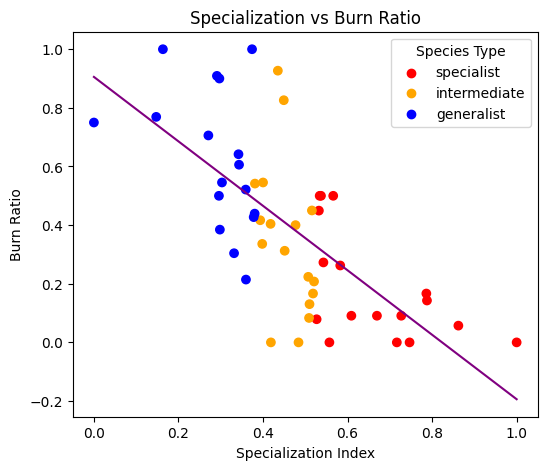

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm

# =========================
# 1. read Excel
# =========================
file_path = "/content/drive/MyDrive/point_count/Specilization/species_specialization_with_burn_ratio_LandSat2.xlsx"
df = pd.read_excel(file_path)

# =========================
# 2. remove na
# =========================
df = df.dropna(subset=["specialization_index", "burn_ratio"])

print("Number of species used:", len(df))

# =========================
# 3. Pearson + Spearman
# =========================
pearson_r, pearson_p = pearsonr(
    df["specialization_index"],
    df["burn_ratio"]
)

spearman_r, spearman_p = spearmanr(
    df["specialization_index"],
    df["burn_ratio"]
)

print("\n=== Correlation Results ===")
print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.4f}")
print(f"Spearman rho = {spearman_r:.3f}, p = {spearman_p:.4f}")

# =========================
# 4. regression
# =========================
X = df["specialization_index"]
y = df["burn_ratio"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print("\n=== Regression Summary ===")
print(model.summary())

# =========================
# 5. plot
# =========================
color_map = {
    "specialist": "red",
    "intermediate": "orange",
    "generalist": "blue"
}

colors = df["specialization_class"].map(color_map)

plt.figure(figsize=(6,5))

plt.scatter(
    df["specialization_index"],
    df["burn_ratio"],
    c=colors
)

# trend line
z = np.polyfit(df["specialization_index"], df["burn_ratio"], 1)
p = np.poly1d(z)

plt.plot(
    df["specialization_index"],
    p(df["specialization_index"]),
    linestyle='-', color= "purple"
)

plt.xlabel("Specialization Index")
plt.ylabel("Burn Ratio")
plt.title("Specialization vs Burn Ratio")

# legend
for label, color in color_map.items():
    plt.scatter([], [], c=color, label=label)

plt.legend(title="Species Type")

plt.show()

# =========================
# 6. save
# =========================
df.to_excel("final_analysis_output.xlsx", index=False)

# **NDVI and LST vs. burn ratio plots and statsitical test**

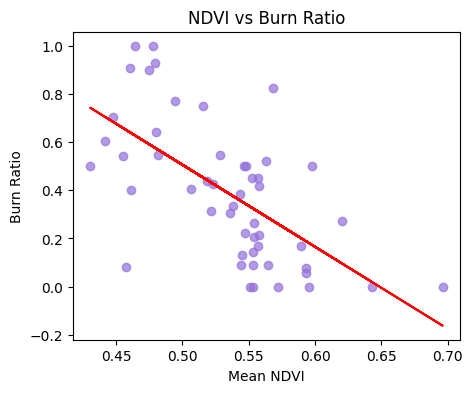

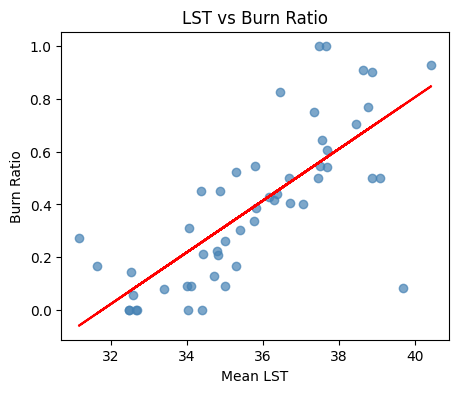

NDVI vs Burn Ratio:
r = -0.633, p = 0.0000

LST vs Burn Ratio:
r = 0.751, p = 0.0000


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

df = final.copy()

# remove na
df = df.dropna(subset=["burn_ratio", "ndvi_mean", "lst_mean"])

# =========================
# 1. NDVI vs burn ratio
# =========================
r_ndvi, p_ndvi = pearsonr(df["ndvi_mean"], df["burn_ratio"])

plt.figure(figsize=(5,4))
plt.scatter(df["ndvi_mean"], df["burn_ratio"], color="mediumpurple", alpha=0.7, label="Species")

# trend line
z = np.polyfit(df["ndvi_mean"], df["burn_ratio"], 1)
p = np.poly1d(z)
plt.plot(df["ndvi_mean"], p(df["ndvi_mean"]), linestyle='-', color="red")

plt.xlabel("Mean NDVI")
plt.ylabel("Burn Ratio")
plt.title(f"NDVI vs Burn Ratio")
plt.ylim()
plt.show()


# =========================
# 2. LST vs burn ratio
# =========================
r_lst, p_lst = pearsonr(df["lst_mean"], df["burn_ratio"])

plt.figure(figsize=(5,4))
plt.scatter(df["lst_mean"], df["burn_ratio"], color="steelblue", alpha=0.7, label="Species")

# trend line
z = np.polyfit(df["lst_mean"], df["burn_ratio"], 1)
p = np.poly1d(z)
plt.plot(df["lst_mean"], p(df["lst_mean"]), linestyle='-', color="red")

plt.xlabel("Mean LST")
plt.ylabel("Burn Ratio")
plt.title(f"LST vs Burn Ratio")
plt.ylim()
plt.show()


# =========================
# print results
# =========================
print("NDVI vs Burn Ratio:")
print(f"r = {r_ndvi:.3f}, p = {p_ndvi:.4f}")

print("\nLST vs Burn Ratio:")
print(f"r = {r_lst:.3f}, p = {p_lst:.4f}")

# **Overall NDVI and LST comparision of burn and unburned site**

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu, ttest_ind

# =========================
# 1. file paths
# =========================
zonal_file = "/content/drive/MyDrive/point_count/zonaldata.xlsx"

# =========================
# 2. read and clean data
# =========================
zonal = pd.read_excel(zonal_file)
zonal = zonal.loc[:, ~zonal.columns.str.contains("^Unnamed")]
zonal.columns = zonal.columns.str.strip()

zonal["site_name"] = zonal["site_name"].astype(str).str.strip().str.lower()
zonal["site_point"] = pd.to_numeric(zonal["site_point"], errors="coerce")

env_cols = [
    "NDVI_2023_LandSat2", "NDVI_2024_LandSat2", "NDVI_2025_LandSat2",
    "LST_2023_LandSat2", "LST_2024_LandSat2", "LST_2025_LandSat2"
]

for col in env_cols:
    zonal[col] = pd.to_numeric(zonal[col], errors="coerce")

# =========================
# 3. define burned / unburned sites
# =========================
burn_sites = ["ember", "chester", "victory", "silver", "cinn"]
unburned_sites = ["eldin", "river", "lassen", "johto", "eagle"]

zonal["burn_status"] = zonal["site_name"].apply(
    lambda x: "burned" if x in burn_sites else ("unburned" if x in unburned_sites else np.nan)
)

# keep only those 10 focal sites
zonal_sub = zonal.dropna(subset=["burn_status"]).copy()

print("Unique focal sites:", sorted(zonal_sub["site_name"].unique()))
print("Rows retained:", len(zonal_sub))

# =========================
# 4. helper function for significance tests
# =========================
def compare_groups(df, value_col, group_col="burn_status"):
    burned = df.loc[df[group_col] == "burned", value_col].dropna()
    unburned = df.loc[df[group_col] == "unburned", value_col].dropna()

    result = {
        "variable": value_col,
        "burned_n": len(burned),
        "unburned_n": len(unburned),
        "burned_mean": burned.mean(),
        "burned_sd": burned.std(),
        "unburned_mean": unburned.mean(),
        "unburned_sd": unburned.std(),
        "difference_burned_minus_unburned": burned.mean() - unburned.mean()
    }

    # Welch t-test
    t_stat, t_p = ttest_ind(burned, unburned, equal_var=False, nan_policy="omit")
    result["welch_t"] = t_stat
    result["welch_p"] = t_p

    # Mann-Whitney U
    u_stat, u_p = mannwhitneyu(burned, unburned, alternative="two-sided")
    result["mw_u"] = u_stat
    result["mw_p"] = u_p

    return result

# =========================
# 5. OVERALL comparison across all years
#    make a long-format table for NDVI and LST
# =========================
overall_frames = []
for yr in ["2023", "2024", "2025"]:
    temp = zonal_sub[["site_name", "site_point", "burn_status", f"NDVI_{yr}", f"Temperature_{yr}"]].copy()
    temp = temp.rename(columns={
        f"NDVI_{yr}": "ndvi",
        f"Temperature_{yr}": "lst"
    })
    temp["year"] = int(yr)
    overall_frames.append(temp)

env_long = pd.concat(overall_frames, ignore_index=True)

# overall tests
overall_ndvi = compare_groups(env_long, "ndvi")
overall_lst = compare_groups(env_long, "lst")

overall_results = pd.DataFrame([overall_ndvi, overall_lst]).round(4)

print("\n=== OVERALL burned vs unburned ===")
print(overall_results)

# =========================
# 6. YEAR-BY-YEAR comparison
# =========================
yearly_results = []

for yr in ["2023", "2024", "2025"]:
    # NDVI
    ndvi_res = compare_groups(zonal_sub, f"NDVI_{yr}")
    ndvi_res["year"] = int(yr)
    ndvi_res["metric"] = "NDVI"
    yearly_results.append(ndvi_res)

    # LST
    lst_res = compare_groups(zonal_sub, f"Temperature_{yr}")
    lst_res["year"] = int(yr)
    lst_res["metric"] = "LST"
    yearly_results.append(lst_res)

yearly_results_df = pd.DataFrame(yearly_results)

# prettier ordering
yearly_results_df = yearly_results_df[
    [
        "year", "metric", "variable",
        "burned_n", "unburned_n",
        "burned_mean", "burned_sd",
        "unburned_mean", "unburned_sd",
        "difference_burned_minus_unburned",
        "welch_t", "welch_p",
        "mw_u", "mw_p"
    ]
].round(4)

print("\n=== YEAR-BY-YEAR burned vs unburned ===")
print(yearly_results_df)

# =========================
# 7. interpretation flags
# =========================
yearly_results_df["significant_ttest"] = yearly_results_df["welch_p"] < 0.05
yearly_results_df["significant_mw"] = yearly_results_df["mw_p"] < 0.05

print("\n=== SIGNIFICANCE FLAGS ===")
print(yearly_results_df[["year", "metric", "burned_mean", "unburned_mean", "difference_burned_minus_unburned", "welch_p", "mw_p", "significant_ttest", "significant_mw"]])

# =========================
# 8. save outputs
# =========================
overall_results.to_excel("overall_burned_unburned_ndvi_lst.xlsx", index=False)
yearly_results_df.to_excel("yearly_burned_unburned_ndvi_lst.xlsx", index=False)

print("\nSaved:")
print("- overall_burned_unburned_ndvi_lst.xlsx")
print("- yearly_burned_unburned_ndvi_lst.xlsx")

Unique focal sites: ['cinn', 'eagle', 'eldin', 'ember', 'johto', 'lassen', 'river', 'silver', 'victory']
Rows retained: 91

=== OVERALL burned vs unburned ===
  variable  burned_n  unburned_n  burned_mean  burned_sd  unburned_mean  \
0     ndvi       123         111       0.6267     0.0954         0.7542   
1      lst       105         111      17.9581     2.4239        17.3158   

   unburned_sd  difference_burned_minus_unburned  welch_t  welch_p    mw_u  \
0       0.0715                           -0.1276 -11.6411   0.0000  1797.5   
1       2.2017                            0.6424   2.0352   0.0431  7006.0   

     mw_p  
0  0.0000  
1  0.0103  

=== YEAR-BY-YEAR burned vs unburned ===
   year metric          variable  burned_n  unburned_n  burned_mean  \
0  2023   NDVI         NDVI_2023        41          37       0.5850   
1  2023    LST  Temperature_2023        35          37      15.4394   
2  2024   NDVI         NDVI_2024        41          37       0.6230   
3  2024    LST  Tem

# **Overall NDVI and LST comparision of burn and unburned site plots**

/tmp/ipykernel_430/2846399153.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([burned_ndvi, unburned_ndvi], labels=["Burned", "Unburned"])
/tmp/ipykernel_430/2846399153.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([burned_lst, unburned_lst], labels=["Burned", "Unburned"])


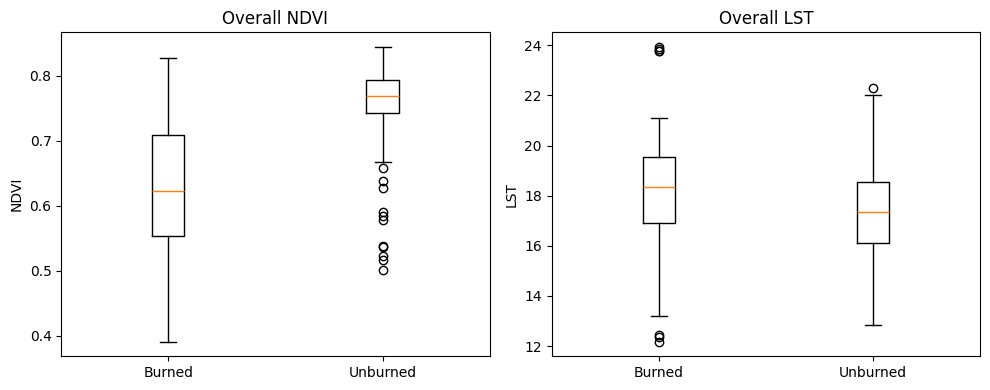

In [ ]:
import matplotlib.pyplot as plt

# OVERALL boxplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

burned_ndvi = env_long.loc[env_long["burn_status"] == "burned", "ndvi"].dropna()
unburned_ndvi = env_long.loc[env_long["burn_status"] == "unburned", "ndvi"].dropna()

burned_lst = env_long.loc[env_long["burn_status"] == "burned", "lst"].dropna()
unburned_lst = env_long.loc[env_long["burn_status"] == "unburned", "lst"].dropna()

axes[0].boxplot([burned_ndvi, unburned_ndvi], labels=["Burned", "Unburned"])
axes[0].set_title("Overall NDVI")
axes[0].set_ylabel("NDVI")

axes[1].boxplot([burned_lst, unburned_lst], labels=["Burned", "Unburned"])
axes[1].set_title("Overall LST")
axes[1].set_ylabel("LST")

plt.tight_layout()
plt.show()

# **fire tolerance**

In [ ]:
import pandas as pd
import numpy as np
from google.colab import files

# =========================
# 1. make sure species_summary is already filtered
# =========================
species_summary_filtered = species_summary[
    (species_summary["n_records"] >= 3) &
    (species_summary["n_sites"] >= 2)
].copy()

print("Filtered species:", len(species_summary_filtered))

# =========================
# 2. define burned sites
# =========================
burned_sites = ["ember", "chester", "victory", "silver", "cinn"]

data_long["site"] = data_long["site"].astype(str).str.strip().str.lower()
data_long["burned"] = data_long["site"].isin(burned_sites)

# =========================
# 3. calculate burn ratio
# =========================
burn_ratio = (
    data_long
    .groupby("species")
    .agg(
        burned_obs=("burned", "sum"),
        total_obs=("burned", "size"),
        burn_ratio=("burned", "mean")
    )
    .reset_index()
)

# keep only filtered species
fire_tolerance = burn_ratio[
    burn_ratio["species"].isin(species_summary_filtered["species"])
].copy()

# =========================
# 4. merge specialization index
# =========================
fire_tolerance = fire_tolerance.merge(
    species_summary_filtered[
        ["species", "specialization_index", "specialization_class"]
    ],
    on="species",
    how="left"
)

# =========================
# 5. calculate Fire Tolerance Index
# =========================
fire_tolerance["generalism"] = 1 - fire_tolerance["specialization_index"]

fire_tolerance["fire_tolerance_index"] = (
    fire_tolerance["burn_ratio"] *
    fire_tolerance["generalism"]
)

fire_tolerance = fire_tolerance.sort_values(
    "fire_tolerance_index",
    ascending=False
).reset_index(drop=True)

# =========================
# 6. save + download
# =========================
out_file = "fire_tolerance_index_filtered_LandSat2.xlsx"

fire_tolerance.to_excel(out_file, index=False)

print("Final species in Fire Tolerance table:", len(fire_tolerance))
print(fire_tolerance.head(20))

files.download(out_file)

Filtered species: 51
Final species in Fire Tolerance table: 51
   species  burned_obs  total_obs  burn_ratio  specialization_index  \
0     WIWA           6          6    1.000000              0.121645   
1     TRES           9         12    0.750000              0.000000   
2     BBWO          60         66    0.909091              0.257022   
3     HOWR          30         39    0.769231              0.140853   
4     MOBL          81         90    0.900000              0.267918   
5     RTHA           6          6    1.000000              0.342833   
6     LAZB         114        123    0.926829              0.382998   
7     LISP          36         51    0.705882              0.232610   
8     GTTO          57         69    0.826087              0.396112   
9     OSFL         129        201    0.641791              0.297506   
10    CAFI          60         99    0.606061              0.298005   
11    MGWA          18         33    0.545455              0.261173   
12    WHWO    

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np

# =========================
# 1. file path
# =========================
bird_file = "/content/drive/MyDrive/point_count/Specilization/Point_Counts_Scoring_Xiqiversion.xlsx"

# =========================
# 2. read and clean point count data
# =========================
birds = pd.read_excel(bird_file)
birds = birds.loc[:, ~birds.columns.str.contains("^Unnamed")]
birds.columns = birds.columns.str.strip()

birds["site"] = birds["site"].astype(str).str.strip().str.lower()
birds["Species"] = birds["Species"].astype(str).str.strip()

# keep only focal sites
birds["burn_status"] = birds["site"].apply(
    lambda x: "burned" if x in burn_sites else ("unburned" if x in unburned_sites else np.nan)
)

birds_sub = birds.dropna(subset=["burn_status"]).copy()

# =========================
# 3. count observations by species and burn status
# =========================
species_burn = (
    birds_sub.groupby(["Species", "burn_status"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# if one column is missing for any reason, create it
if "burned" not in species_burn.columns:
    species_burn["burned"] = 0
if "unburned" not in species_burn.columns:
    species_burn["unburned"] = 0

# total observations
species_burn["total_obs"] = species_burn["burned"] + species_burn["unburned"]

# fire tolerance index (0 to 1)
species_burn["fire_tolerance_index"] = species_burn["burned"] / species_burn["total_obs"]

# centered version (-1 to 1)
species_burn["fire_tolerance_centered"] = 2 * species_burn["fire_tolerance_index"] - 1

# optional category
species_burn["fire_association"] = pd.cut(
    species_burn["fire_tolerance_index"],
    bins=[-0.01, 0.33, 0.66, 1.01],
    labels=["unburned-associated", "mixed", "burned-associated"]
)

species_burn = species_burn.sort_values("fire_tolerance_index", ascending=False).reset_index(drop=True)

print("\n=== FIRE TOLERANCE INDEX TABLE ===")
print(species_burn.head(20))

species_burn.to_excel("species_fire_tolerance_index.xlsx", index=False)
print("\nSaved: species_fire_tolerance_index.xlsx")


=== FIRE TOLERANCE INDEX TABLE ===
burn_status Species  burned  unburned  total_obs  fire_tolerance_index  \
0              BBWO      20         0         20              1.000000   
1              LAZB      38         0         38              1.000000   
2              TRES       3         0          3              1.000000   
3              ROWR       1         0          1              1.000000   
4              RTHA       2         0          2              1.000000   
5              RUHU       1         0          1              1.000000   
6              WIWA       2         0          2              1.000000   
7              WBNU       1         0          1              1.000000   
8             UNKWP       1         0          1              1.000000   
9            UNKHUM       1         0          1              1.000000   
10              NHK       1         0          1              1.000000   
11             LEWO       1         0          1              1.000000   
12

# **specialization index and fire tolerance table saving**

In [ ]:
# If you already have a species specialization table loaded as species_summary
# and the species column is named "species":

fti = species_burn.rename(columns={"Species": "species"})

specialization_fire = species_summary.merge(
    fti[["species", "fire_tolerance_index", "fire_tolerance_centered", "fire_association"]],
    on="species",
    how="left"
)

specialization_fire.to_excel("specialization_with_fire_tolerance.xlsx", index=False)
print("Saved: specialization_with_fire_tolerance.xlsx")

Saved: specialization_with_fire_tolerance.xlsx


In [ ]:
from google.colab import files

files.download("specialization_with_fire_tolerance.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **spreadsheets download**

In [ ]:
from google.colab import files

files.download("overall_burned_unburned_ndvi_lst.xlsx")
files.download("yearly_burned_unburned_ndvi_lst.xlsx")
files.download("species_fire_tolerance_index.xlsx")

FileNotFoundError: Cannot find file: overall_burned_unburned_ndvi_lst.xlsx

# **saperate overall NDVI and LST in burned and unburned sites plots**
### **just easy to formatting in the document and saving**

/tmp/ipykernel_430/349741869.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([burned_ndvi, unburned_ndvi], labels=["Burned", "Unburned"])


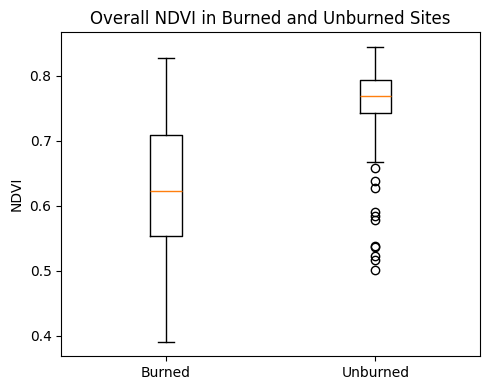

In [ ]:
import matplotlib.pyplot as plt

burned_ndvi = env_long.loc[env_long["burn_status"] == "burned", "ndvi"].dropna()
unburned_ndvi = env_long.loc[env_long["burn_status"] == "unburned", "ndvi"].dropna()

plt.figure(figsize=(5, 4))
plt.boxplot([burned_ndvi, unburned_ndvi], labels=["Burned", "Unburned"])
plt.title("Overall NDVI in Burned and Unburned Sites")
plt.ylabel("NDVI")
plt.tight_layout()
plt.savefig("ndvi_burned_unburned.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_430/2223465298.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([burned_lst, unburned_lst], labels=["Burned", "Unburned"])


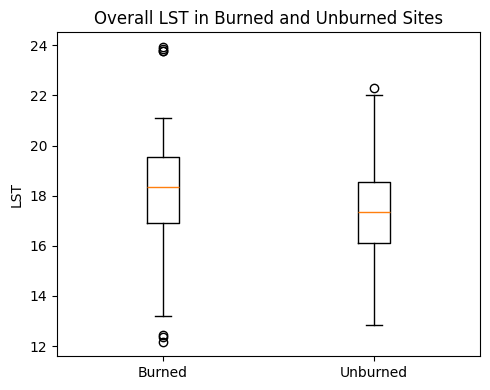

In [ ]:
burned_lst = env_long.loc[env_long["burn_status"] == "burned", "lst"].dropna()
unburned_lst = env_long.loc[env_long["burn_status"] == "unburned", "lst"].dropna()

plt.figure(figsize=(5, 4))
plt.boxplot([burned_lst, unburned_lst], labels=["Burned", "Unburned"])
plt.title("Overall LST in Burned and Unburned Sites")
plt.ylabel("LST")
plt.tight_layout()
plt.savefig("lst_burned_unburned.png", dpi=300, bbox_inches="tight")
plt.show()

# **year by year comparision of NDVI and LST at burned and unburned and statistical test**

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, mannwhitneyu

# =========================
# 1. data
# =========================
zonal = pd.read_excel("/content/drive/MyDrive/point_count/zonaldata.xlsx")
zonal = zonal.loc[:, ~zonal.columns.str.contains("^Unnamed")]
zonal.columns = zonal.columns.str.strip()

zonal["site_name"] = zonal["site_name"].astype(str).str.lower().str.strip()

# =========================
# 2. define burned / unburned
# =========================
burn_sites = ["ember", "chester", "victory", "silver", "cinn"]
unburned_sites = ["eldin", "river", "lassen", "johto", "eagle"]

zonal["burn_status"] = zonal["site_name"].apply(
    lambda x: "burned" if x in burn_sites else ("unburned" if x in unburned_sites else np.nan)
)

zonal = zonal.dropna(subset=["burn_status"])

# =========================
# 3. statistic test
# =========================
def test_difference(df, var):
    burned = df[df["burn_status"] == "burned"][var].dropna()
    unburned = df[df["burn_status"] == "unburned"][var].dropna()

    t_stat, t_p = ttest_ind(burned, unburned, equal_var=False)
    u_stat, u_p = mannwhitneyu(burned, unburned, alternative="two-sided")

    return {
        "burned_mean": burned.mean(),
        "unburned_mean": unburned.mean(),
        "difference": burned.mean() - unburned.mean(),
        "welch_t": t_stat,
        "welch_p": t_p,
        "mw_u": u_stat,
        "mw_p": u_p,
        "significant_t": t_p < 0.05,
        "significant_mw": u_p < 0.05
    }

# =========================
# 4. yearly NDVI + LST
# =========================
results = []

years = ["2023", "2024", "2025"]

for year in years:
    # NDVI
    ndvi_res = test_difference(zonal, f"NDVI_{year}_LandSat2")
    ndvi_res["year"] = year
    ndvi_res["variable"] = "NDVI"
    results.append(ndvi_res)

    # LST
    lst_res = test_difference(zonal, f"LST_{year}_LandSat2")
    lst_res["year"] = year
    lst_res["variable"] = "LST"
    results.append(lst_res)

results_df = pd.DataFrame(results)

# order
results_df = results_df[
    ["year", "variable",
     "burned_mean", "unburned_mean", "difference",
     "welch_t", "welch_p",
     "mw_u", "mw_p",
     "significant_t", "significant_mw"]
].round(4)

# =========================
# 5. output
# =========================
print("\n=== YEAR-BY-YEAR RESULTS ===")
print(results_df)

# =========================
# 6. answer
# =========================
print("\n=== INTERPRETATION ===")

for var in ["NDVI", "LST"]:
    subset = results_df[results_df["variable"] == var]

    sig_years = subset[subset["significant_t"] == True]["year"].tolist()

    if len(sig_years) == 3:
        print(f"{var}: Significant in ALL years → strong consistent difference")
    elif len(sig_years) > 0:
        print(f"{var}: Significant ONLY in {sig_years} → partial / inconsistent effect")
    else:
        print(f"{var}: NOT significant in any year → no clear difference")

# =========================
# 7. save
# =========================
results_df.to_excel("yearly_ndvi_lst_significance.xlsx", index=False)
print("\nSaved: yearly_ndvi_lst_significance.xlsx")


=== YEAR-BY-YEAR RESULTS ===
   year variable  burned_mean  unburned_mean  difference  welch_t  welch_p  \
0  2023     NDVI       0.3980         0.5677     -0.1697  -7.5192   0.0000   
1  2023      LST      45.0448        38.5360      6.5088   7.3003   0.0000   
2  2024     NDVI       0.4821         0.5733     -0.0913  -3.5055   0.0008   
3  2024      LST      31.4345        25.6961      5.7385   7.7697   0.0000   
4  2025     NDVI       0.5251         0.5864     -0.0613  -2.3954   0.0196   
5  2025      LST      39.7018        36.5719      3.1299   4.3070   0.0000   

     mw_u    mw_p  significant_t  significant_mw  
0   253.0  0.0000           True            True  
1  1770.0  0.0000           True            True  
2   685.0  0.0068           True            True  
3  1828.5  0.0000           True            True  
4   783.0  0.0541           True           False  
5  1499.0  0.0002           True            True  

=== INTERPRETATION ===
NDVI: Significant in ALL years → strong co

# **spreadsheet download**

In [ ]:
from google.colab import files

files.download("yearly_ndvi_lst_significance.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **NDVI comparision of burned and unburned sites from 2023-2025 plot**

/tmp/ipykernel_430/3673822148.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)


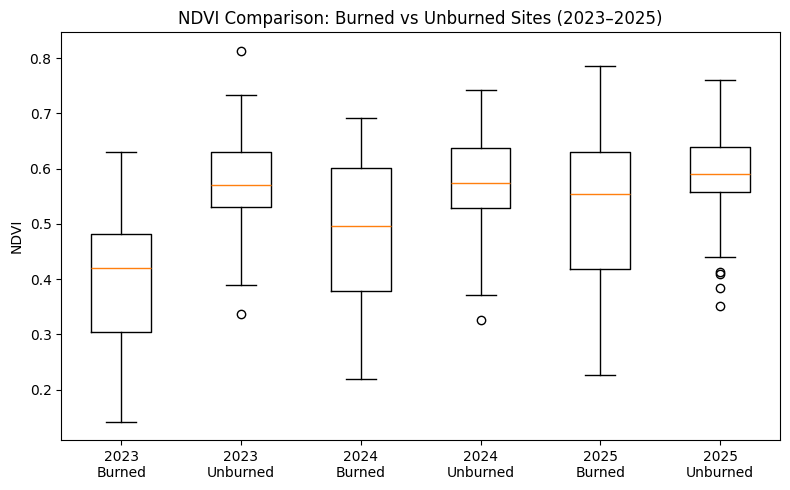

In [ ]:
import matplotlib.pyplot as plt

years = ["2023", "2024", "2025"]

plt.figure(figsize=(8, 5))

data_to_plot = []
labels = []

for year in years:
    burned = zonal.loc[zonal["burn_status"] == "burned", f"NDVI_{year}_LandSat2"].dropna()
    unburned = zonal.loc[zonal["burn_status"] == "unburned", f"NDVI_{year}_LandSat2"].dropna()

    data_to_plot.extend([burned, unburned])
    labels.extend([f"{year}\nBurned", f"{year}\nUnburned"])

plt.boxplot(data_to_plot, labels=labels)

plt.title("NDVI Comparison: Burned vs Unburned Sites (2023–2025)")
plt.ylabel("NDVI")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("ndvi_yearly_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# **LST comparision of burned and unburned sites from 2023-2025 plot**

/tmp/ipykernel_430/2374256141.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)


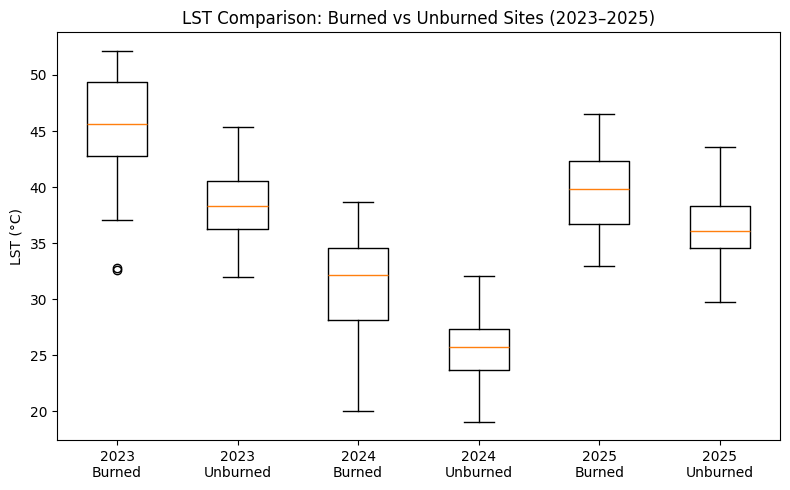

In [ ]:
plt.figure(figsize=(8, 5))

data_to_plot = []
labels = []

for year in years:
    burned = zonal.loc[zonal["burn_status"] == "burned", f"LST_{year}_LandSat2"].dropna()
    unburned = zonal.loc[zonal["burn_status"] == "unburned", f"LST_{year}_LandSat2"].dropna()

    data_to_plot.extend([burned, unburned])
    labels.extend([f"{year}\nBurned", f"{year}\nUnburned"])

plt.boxplot(data_to_plot, labels=labels)

plt.title("LST Comparison: Burned vs Unburned Sites (2023–2025)")
plt.ylabel("LST (°C)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("lst_yearly_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# **just put both year by year and overall and statistical test in the same code section**

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, mannwhitneyu
from google.colab import files

zonal_file = "/content/drive/MyDrive/point_count/zonaldata.xlsx"

zonal = pd.read_excel(zonal_file)
zonal = zonal.loc[:, ~zonal.columns.astype(str).str.contains("^Unnamed")]
zonal.columns = zonal.columns.astype(str).str.strip()

zonal["site_name"] = zonal["site_name"].astype(str).str.strip().str.lower()
zonal["site_point"] = pd.to_numeric(zonal["site_point"], errors="coerce")

env_cols = [
    "NDVI_2023_LandSat2", "NDVI_2024_LandSat2", "NDVI_2025_LandSat2",
    "LST_2023_LandSat2", "LST_2024_LandSat2", "LST_2025_LandSat2"
]

for col in env_cols:
    zonal[col] = pd.to_numeric(zonal[col], errors="coerce")

burn_sites = ["ember", "chester", "victory", "silver", "cinn"]
unburned_sites = ["eldin", "river", "lassen", "johto", "eagle"]

zonal["burn_status"] = zonal["site_name"].apply(
    lambda x: "burned" if x in burn_sites else ("unburned" if x in unburned_sites else np.nan)
)

zonal = zonal.dropna(subset=["burn_status"]).copy()

print("Sites included:", sorted(zonal["site_name"].unique()))
print("Rows included:", len(zonal))

def compare_groups(df, value_col):
    burned = df.loc[df["burn_status"] == "burned", value_col].dropna()
    unburned = df.loc[df["burn_status"] == "unburned", value_col].dropna()

    t_stat, t_p = ttest_ind(burned, unburned, equal_var=False, nan_policy="omit")
    u_stat, u_p = mannwhitneyu(burned, unburned, alternative="two-sided")

    return {
        "variable": value_col,
        "burned_n": len(burned),
        "unburned_n": len(unburned),
        "burned_mean": burned.mean(),
        "burned_sd": burned.std(),
        "unburned_mean": unburned.mean(),
        "unburned_sd": unburned.std(),
        "difference_burned_minus_unburned": burned.mean() - unburned.mean(),
        "welch_t": t_stat,
        "welch_p": t_p,
        "mw_u": u_stat,
        "mw_p": u_p,
        "significant_ttest": t_p < 0.05,
        "significant_mw": u_p < 0.05
    }

overall_frames = []

for yr in ["2023", "2024", "2025"]:
    temp = zonal[
        [
            "site_name",
            "site_point",
            "burn_status",
            f"NDVI_{yr}_LandSat2",
            f"LST_{yr}_LandSat2"
        ]
    ].copy()

    temp = temp.rename(columns={
        f"NDVI_{yr}_LandSat2": "NDVI",
        f"LST_{yr}_LandSat2": "LST"
    })

    temp["year"] = int(yr)
    overall_frames.append(temp)

env_long = pd.concat(overall_frames, ignore_index=True)

overall_ndvi = compare_groups(env_long, "NDVI")
overall_lst = compare_groups(env_long, "LST")

overall_results = pd.DataFrame([overall_ndvi, overall_lst]).round(4)

print("\n=== OVERALL RESULTS LandSat2, 2023–2025 combined ===")
print(overall_results)

yearly_results = []

for yr in ["2023", "2024", "2025"]:
    ndvi_res = compare_groups(zonal, f"NDVI_{yr}_LandSat2")
    ndvi_res["year"] = int(yr)
    ndvi_res["metric"] = "NDVI"
    yearly_results.append(ndvi_res)

    lst_res = compare_groups(zonal, f"LST_{yr}_LandSat2")
    lst_res["year"] = int(yr)
    lst_res["metric"] = "LST"
    yearly_results.append(lst_res)

yearly_results_df = pd.DataFrame(yearly_results)

yearly_results_df = yearly_results_df[
    [
        "year", "metric", "variable",
        "burned_n", "unburned_n",
        "burned_mean", "burned_sd",
        "unburned_mean", "unburned_sd",
        "difference_burned_minus_unburned",
        "welch_t", "welch_p",
        "mw_u", "mw_p",
        "significant_ttest", "significant_mw"
    ]
].round(4)

print("\n=== YEAR-BY-YEAR RESULTS LandSat2 ===")
print(yearly_results_df)

print("\n=== INTERPRETATION ===")

for metric in ["NDVI", "LST"]:
    sub = yearly_results_df[yearly_results_df["metric"] == metric]
    sig_years = sub.loc[sub["significant_ttest"], "year"].tolist()

    if len(sig_years) == 3:
        print(f"{metric}: significant in ALL years based on Welch's t-test.")
    elif len(sig_years) == 0:
        print(f"{metric}: not significant in any year based on Welch's t-test.")
    else:
        print(f"{metric}: significant only in {sig_years} based on Welch's t-test.")

overall_file = "overall_burned_unburned_NDVI_LST_LandSat2.xlsx"
yearly_file = "yearly_burned_unburned_NDVI_LST_LandSat2.xlsx"

overall_results.to_excel(overall_file, index=False)
yearly_results_df.to_excel(yearly_file, index=False)

files.download(overall_file)
files.download(yearly_file)

Sites included: ['cinn', 'eagle', 'eldin', 'ember', 'johto', 'lassen', 'river', 'silver', 'victory']
Rows included: 91

=== OVERALL RESULTS LandSat2, 2023–2025 combined ===
  variable  burned_n  unburned_n  burned_mean  burned_sd  unburned_mean  \
0     NDVI       123         150       0.4684     0.1456         0.5758   
1      LST       123         150      38.7270     7.0139        33.6013   

   unburned_sd  difference_burned_minus_unburned  welch_t  welch_p     mw_u  \
0       0.0887                           -0.1074  -7.1661      0.0   5235.0   
1       6.4275                            5.1257   6.2371      0.0  12721.5   

   mw_p  significant_ttest  significant_mw  
0   0.0               True            True  
1   0.0               True            True  

=== YEAR-BY-YEAR RESULTS LandSat2 ===
   year metric            variable  burned_n  unburned_n  burned_mean  \
0  2023   NDVI  NDVI_2023_LandSat2        41          50       0.3980   
1  2023    LST   LST_2023_LandSat2        4

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, mannwhitneyu

# =========================
# 1. read and clean data
# =========================
zonal_file = "/content/drive/MyDrive/point_count/zonaldata.xlsx"

zonal = pd.read_excel(zonal_file)
zonal = zonal.loc[:, ~zonal.columns.str.contains("^Unnamed")]
zonal.columns = zonal.columns.str.strip()

zonal["site_name"] = zonal["site_name"].astype(str).str.strip().str.lower()
zonal["site_point"] = pd.to_numeric(zonal["site_point"], errors="coerce")

env_cols = [
    "NDVI_2023_LandSat2", "NDVI_2024_LandSat2", "NDVI_2025_LandSat2",
    "LST_2023_LandSat2", "LST_2024_LandSat2", "LST_2025_LandSat2"
]
for col in env_cols:
    zonal[col] = pd.to_numeric(zonal[col], errors="coerce")

# =========================
# 2. define burn status
# =========================
burn_sites = ["ember", "chester", "victory", "silver", "cinn"]
unburned_sites = ["eldin", "river", "lassen", "johto", "eagle"]

zonal["burn_status"] = zonal["site_name"].apply(
    lambda x: "burned" if x in burn_sites else ("unburned" if x in unburned_sites else np.nan)
)

# keep only focal sites
zonal = zonal.dropna(subset=["burn_status"]).copy()

print("Sites included:", sorted(zonal["site_name"].unique()))
print("Rows included:", len(zonal))

# =========================
# 3. helper function
# =========================
def compare_groups(df, value_col):
    burned = df.loc[df["burn_status"] == "burned", value_col].dropna()
    unburned = df.loc[df["burn_status"] == "unburned", value_col].dropna()

    # Welch t-test
    t_stat, t_p = ttest_ind(burned, unburned, equal_var=False, nan_policy="omit")

    # Mann-Whitney U
    u_stat, u_p = mannwhitneyu(burned, unburned, alternative="two-sided")

    return {
        "variable": value_col,
        "burned_n": len(burned),
        "unburned_n": len(unburned),
        "burned_mean": burned.mean(),
        "burned_sd": burned.std(),
        "unburned_mean": unburned.mean(),
        "unburned_sd": unburned.std(),
        "difference_burned_minus_unburned": burned.mean() - unburned.mean(),
        "welch_t": t_stat,
        "welch_p": t_p,
        "mw_u": u_stat,
        "mw_p": u_p,
        "significant_ttest": t_p < 0.05,
        "significant_mw": u_p < 0.05
    }

# =========================
# 4. OVERALL comparison
#    combine 2023–2025 into long format
# =========================
overall_frames = []

for yr in ["2023", "2024", "2025"]:
    temp = zonal[["site_name", "site_point", "burn_status", f"NDVI_{yr}", f"Temperature_{yr}"]].copy()
    temp = temp.rename(columns={
        f"NDVI_{yr}": "NDVI",
        f"Temperature_{yr}": "LST"
    })
    temp["year"] = int(yr)
    overall_frames.append(temp)

env_long = pd.concat(overall_frames, ignore_index=True)

overall_ndvi = compare_groups(env_long, "NDVI")
overall_lst = compare_groups(env_long, "LST")

overall_results = pd.DataFrame([overall_ndvi, overall_lst]).round(4)

print("\n=== OVERALL RESULTS (2023–2025 combined) ===")
print(overall_results)

# =========================
# 5. YEAR-BY-YEAR comparison
# =========================
yearly_results = []

for yr in ["2023", "2024", "2025"]:
    ndvi_res = compare_groups(zonal, f"NDVI_{yr}")
    ndvi_res["year"] = int(yr)
    ndvi_res["metric"] = "NDVI"
    yearly_results.append(ndvi_res)

    lst_res = compare_groups(zonal, f"Temperature_{yr}")
    lst_res["year"] = int(yr)
    lst_res["metric"] = "LST"
    yearly_results.append(lst_res)

yearly_results_df = pd.DataFrame(yearly_results)

yearly_results_df = yearly_results_df[
    [
        "year", "metric", "variable",
        "burned_n", "unburned_n",
        "burned_mean", "burned_sd",
        "unburned_mean", "unburned_sd",
        "difference_burned_minus_unburned",
        "welch_t", "welch_p",
        "mw_u", "mw_p",
        "significant_ttest", "significant_mw"
    ]
].round(4)

print("\n=== YEAR-BY-YEAR RESULTS ===")
print(yearly_results_df)

# =========================
# 6. simple interpretation
# =========================
print("\n=== INTERPRETATION ===")

for metric in ["NDVI", "LST"]:
    sub = yearly_results_df[yearly_results_df["metric"] == metric]
    sig_years = sub.loc[sub["significant_ttest"], "year"].tolist()

    if len(sig_years) == 3:
        print(f"{metric}: significant in ALL years based on Welch's t-test.")
    elif len(sig_years) == 0:
        print(f"{metric}: not significant in any year based on Welch's t-test.")
    else:
        print(f"{metric}: significant only in {sig_years} based on Welch's t-test.")

# =========================
# 7. save outputs
# =========================
overall_results.to_excel("overall_burned_unburned_ndvi_lst.xlsx", index=False)
yearly_results_df.to_excel("yearly_burned_unburned_ndvi_lst.xlsx", index=False)

print("\nSaved files:")
print("- overall_burned_unburned_ndvi_lst.xlsx")
print("- yearly_burned_unburned_ndvi_lst.xlsx")

Sites included: ['cinn', 'eagle', 'eldin', 'ember', 'johto', 'lassen', 'river', 'silver', 'victory']
Rows included: 91

=== OVERALL RESULTS (2023–2025 combined) ===
  variable  burned_n  unburned_n  burned_mean  burned_sd  unburned_mean  \
0     NDVI       123         111       0.6267     0.0954         0.7542   
1      LST       105         111      17.9581     2.4239        17.3158   

   unburned_sd  difference_burned_minus_unburned  welch_t  welch_p    mw_u  \
0       0.0715                           -0.1276 -11.6411   0.0000  1797.5   
1       2.2017                            0.6424   2.0352   0.0431  7006.0   

     mw_p  significant_ttest  significant_mw  
0  0.0000               True            True  
1  0.0103               True            True  

=== YEAR-BY-YEAR RESULTS ===
   year metric          variable  burned_n  unburned_n  burned_mean  \
0  2023   NDVI         NDVI_2023        41          37       0.5850   
1  2023    LST  Temperature_2023        35          37      1

### **NDVI LST in LandSat Level 2**

In [ ]:
!pip install rasterio geopandas openpyxl -q

import rasterio
import numpy as np
import pandas as pd
import geopandas as gpd

# read lat and lon
df = pd.read_excel(
    "/content/drive/MyDrive/point_count/zonaldata.xlsx"
)

# lat and lon
lat_col = "laitude"
lon_col = "longitude"

# convert GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(
        df[lon_col],
        df[lat_col]
    ),
    crs="EPSG:4326"
)

files_dict = {
    2023: {
        "B4": "/content/drive/MyDrive/point_count/redoNDVI/2023B4.TIF",
        "B5": "/content/drive/MyDrive/point_count/redoNDVI/2023B5.TIF"
    },
    2024: {
        "B4": "/content/drive/MyDrive/point_count/redoNDVI/2024B4.TIF",
        "B5": "/content/drive/MyDrive/point_count/redoNDVI/2024B5.TIF"
    },
    2025: {
        "B4": "/content/drive/MyDrive/point_count/redoNDVI/2025B4.TIF",
        "B5": "/content/drive/MyDrive/point_count/redoNDVI/2025B5.TIF"
    }
}

for year, paths in files_dict.items():

    with rasterio.open(paths["B4"]) as src:
        b4 = src.read(1).astype(float)
        transform = src.transform
        raster_crs = src.crs

    with rasterio.open(paths["B5"]) as src:
        b5 = src.read(1).astype(float)

    # Landsat Collection 2 Level 2 Surface Reflectance
    b4_sr = b4 * 0.0000275 - 0.2
    b5_sr = b5 * 0.0000275 - 0.2

    ndvi = (b5_sr - b4_sr) / (b5_sr + b4_sr)

    ndvi[(ndvi < -1) | (ndvi > 1)] = np.nan

    gdf_proj = gdf.to_crs(raster_crs)

    values = []

    for pt in gdf_proj.geometry:

        try:
            row, col = rasterio.transform.rowcol(
                transform,
                pt.x,
                pt.y
            )

            values.append(float(ndvi[row, col]))

        except:
            values.append(np.nan)

    df[f"NDVI_{year}_LandSat2"] = values

# export Excel
output_file = "/content/NDVI_added.xlsx"

df.to_excel(
    output_file,
    index=False
)

print(df.head())
print("Done!")

   OBJECTID site_name  site_point    laitude   longitude  \
0         1     ember           1  40.446249 -121.086899   
1         2     ember           3  40.434310 -121.086287   
2         3     ember           4  40.441587 -121.079581   
3         4     ember           5  40.437020 -121.082261   
4         5     ember           6  40.443367 -121.075335   

   Sites2023_NDVI_2023_bin  Sites2024_NDVI_2024_bin  Sites2025_NDVI_2025_bin  \
0                      6.0                      7.0                      8.0   
1                      7.0                      7.0                      8.0   
2                      7.0                      7.0                      7.0   
3                      7.0                      8.0                      8.0   
4                      8.0                      8.0                      8.0   

   sites_point_in_range_2023  sites_point_in_range_2024  ...  \
0                        1.0                        1.0  ...   
1                        2.0  

In [ ]:
from google.colab import files
files.download("/content/NDVI_added.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(df[["NDVI_2023","NDVI_2024","NDVI_2025"]].describe())

        NDVI_2023   NDVI_2024   NDVI_2025
count  102.000000  102.000000  102.000000
mean     0.490625    0.536570    0.563328
std      0.138072    0.132639    0.123460
min      0.142048    0.219488    0.225918
25%      0.402859    0.472533    0.504213
50%      0.491141    0.566561    0.583406
75%      0.577410    0.618097    0.639006
max      0.813192    0.816670    0.812653


In [ ]:
!pip install rasterio pandas geopandas openpyxl -q

import rasterio
import numpy as np
import pandas as pd
import geopandas as gpd

df = pd.read_excel("/content/drive/MyDrive/point_count/zonaldata.xlsx")
df.columns = df.columns.str.strip()

print(df.columns.tolist())

lat_col = "laitude"
lon_col = "longitude"

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
    crs="EPSG:4326"
)

lst_files = {
    2023: "/content/drive/MyDrive/point_count/redoLST/2023B10.TIF",
    2024: "/content/drive/MyDrive/point_count/redoLST/2024B10.TIF",
    2025: "/content/drive/MyDrive/point_count/redoLST/2025B10.TIF"
}

def extract_lst_points(lst_path, gdf):
    with rasterio.open(lst_path) as src:
        st = src.read(1).astype("float32")
        transform = src.transform
        raster_crs = src.crs

        # Landsat Collection 2 Level 2 ST_B10 -> Celsius
        lst_c = st * 0.00341802 + 149.0 - 273.15

        # remove obvious invalid values
        lst_c[(st == 0) | (lst_c < -20) | (lst_c > 80)] = np.nan

        gdf_proj = gdf.to_crs(raster_crs)

        values = []
        for pt in gdf_proj.geometry:
            try:
                row, col = rasterio.transform.rowcol(transform, pt.x, pt.y)
                values.append(float(lst_c[row, col]))
            except:
                values.append(np.nan)

    return values

for year, path in lst_files.items():
    df[f"LST_{year}"] = extract_lst_points(path, gdf)

out = "/content/zonaldata_with_LST.xlsx"
df.to_excel(out, index=False)

print(df[["LST_2023", "LST_2024", "LST_2025"]].describe())
print("Done:", out)

['OBJECTID', 'site_name', 'site_point', 'laitude', 'longitude', 'NDVI_2023', 'NDVI_2024', 'NDVI_2025', 'Temperature_2023', 'Temperature_2024', 'Temperature_2025', 'Temperature_2023_LandSat1', 'Temperature_2024_LandSat1', 'Temperature_2025_LandSat1', 'NDVI_2023_LandSat2', 'NDVI_2024_LandSat2', 'NDVI_2025_LandSat2', 'bin', 'range (%)', 'Unnamed: 19', 'NDVI_2023_LandSat', 'NDVI_2024_LandSat', 'NDVI_2024_LandSat.1']
         LST_2023    LST_2024    LST_2025
count  102.000000  102.000000  102.000000
mean    41.586910   28.372878   37.860367
std      5.114744    4.470834    3.946643
min     32.019318   19.099213   29.527618
25%     37.217293   25.046600   35.211761
50%     41.400101   27.912567   37.662506
75%     45.162476   31.966339   40.569519
max     52.148041   38.643463   46.522003
Done: /content/zonaldata_with_LST.xlsx


In [ ]:
from google.colab import files
files.download("/content/zonaldata_with_LST.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### **NDVI LandSat Level 1**

In [ ]:
!pip install rasterio geopandas openpyxl -q

import rasterio
import numpy as np
import pandas as pd
import geopandas as gpd

# read lat and lon
df = pd.read_excel(
    "/content/drive/MyDrive/point_count/zonaldata.xlsx"
)

# lat and lon
lat_col = "laitude"
lon_col = "longitude"

# convert GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(
        df[lon_col],
        df[lat_col]
    ),
    crs="EPSG:4326"
)

files_dict = {
    2023: {
        "B4": "/content/drive/MyDrive/point_count/redoNDVI/L12023B4.TIF",
        "B5": "/content/drive/MyDrive/point_count/redoNDVI/L12023B5.TIF"
    },
    2024: {
        "B4": "/content/drive/MyDrive/point_count/redoNDVI/L12024B4.TIF",
        "B5": "/content/drive/MyDrive/point_count/redoNDVI/L12024B5.TIF"
    },
    2025: {
        "B4": "/content/drive/MyDrive/point_count/redoNDVI/L12025B4.TIF",
        "B5": "/content/drive/MyDrive/point_count/redoNDVI/L12025B5.TIF"
    }
}

for year, paths in files_dict.items():

    with rasterio.open(paths["B4"]) as src:
        b4 = src.read(1).astype(float)
        transform = src.transform
        raster_crs = src.crs

    with rasterio.open(paths["B5"]) as src:
        b5 = src.read(1).astype(float)

    # Landsat Collection 2 Level 2 Surface Reflectance
    b4_sr = b4 * 0.0000275 - 0.2
    b5_sr = b5 * 0.0000275 - 0.2

    ndvi = (b5_sr - b4_sr) / (b5_sr + b4_sr)

    ndvi[(ndvi < -1) | (ndvi > 1)] = np.nan

    gdf_proj = gdf.to_crs(raster_crs)

    values = []

    for pt in gdf_proj.geometry:

        try:
            row, col = rasterio.transform.rowcol(
                transform,
                pt.x,
                pt.y
            )

            values.append(float(ndvi[row, col]))

        except:
            values.append(np.nan)

    df[f"NDVI_{year}_LandSat2"] = values

# export Excel
output_file = "/content/NDVIL1_added.xlsx"

df.to_excel(
    output_file,
    index=False
)

print(df.head())
print("Done!")

   OBJECTID site_name  site_point    laitude   longitude  NDVI_2023  \
0         1     ember           1  40.446249 -121.086899   0.541879   
1         2     ember           3  40.434310 -121.086287   0.739497   
2         3     ember           4  40.441587 -121.079581   0.712985   
3         4     ember           5  40.437020 -121.082261   0.613927   
4         5     ember           6  40.443367 -121.075335   0.748670   

   NDVI_2024  NDVI_2025  Temperature_2023  Temperature_2024  ...  \
0   0.800492   0.857806         15.386322         17.840570  ...   
1   0.872379   0.899848         18.049459         18.912315  ...   
2   0.739559   0.756165         17.619139         17.746042  ...   
3   0.801604   0.858784         18.278576         18.564802  ...   
4   0.759069   0.777990         18.492270         17.215183  ...   

   NDVI_2023_LandSat2  NDVI_2024_LandSat2  NDVI_2025_LandSat2  \
0            0.373584            0.603703            0.678193   
1            0.548817            0

In [ ]:
from google.colab import files
files.download("/content/NDVIL1_added.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
before = data_long["species"].nunique()
after = len(species_summary)

print("Species before filtering:", before)
print("Species after filtering:", after)
print("Species removed:", before - after)

NameError: name 'data_long' is not defined